# Disease Prediction + Doctor Specialty Recommendation

### Step 1 - Import & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW_DIR = "../data/raw/"
PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"

files = os.listdir(RAW_DIR)
print("File yang ada:", files)

File yang ada: ['Disease precaution.csv', 'DiseaseAndSymptoms.csv', 'Disease_Description.csv', 'Doctor_Specialist.csv', 'Doctor_Versus_Disease.csv', 'Specialist.xlsx']


In [2]:
dataframes = {}

for f in os.listdir(RAW_DIR):
    path = os.path.join(RAW_DIR, f)

    if f.endswith('.csv'):
        try:
            dataframes[f] = pd.read_csv(path)
        except UnicodeDecodeError:
            dataframes[f] = pd.read_csv(path, encoding='latin1')

    elif f.endswith('.xlsx') or f.endswith('.xls'):
        dataframes[f] = pd.read_excel(path)

for f, df in dataframes.items():
    print(f"{f}: {df.shape}")

Disease precaution.csv: (41, 5)
DiseaseAndSymptoms.csv: (4920, 18)
Disease_Description.csv: (41, 2)
Doctor_Specialist.csv: (19, 1)
Doctor_Versus_Disease.csv: (40, 2)
Specialist.xlsx: (4920, 133)


### Step 2 - cek file xlsx

In [3]:
xlsx_files = [f for f in dataframes if f.endswith('.xlsx')]
for f in xlsx_files:
    print(f"\n=== {f} ===")
    print(dataframes[f].shape)
    print(dataframes[f].columns.tolist())
    print(dataframes[f].head())


=== Specialist.xlsx ===
(4920, 133)
['Unnamed: 0', 'itching', ' skin_rash', ' nodal_skin_eruptions', ' dischromic _patches', ' continuous_sneezing', ' shivering', ' chills', ' watering_from_eyes', ' stomach_pain', ' acidity', ' ulcers_on_tongue', ' vomiting', ' cough', ' chest_pain', ' yellowish_skin', ' nausea', ' loss_of_appetite', ' abdominal_pain', ' yellowing_of_eyes', ' burning_micturition', ' spotting_ urination', ' passage_of_gases', ' internal_itching', ' indigestion', ' muscle_wasting', ' patches_in_throat', ' high_fever', ' extra_marital_contacts', ' fatigue', ' weight_loss', ' restlessness', ' lethargy', ' irregular_sugar_level', ' blurred_and_distorted_vision', ' obesity', ' excessive_hunger', ' increased_appetite', ' polyuria', ' sunken_eyes', ' dehydration', ' diarrhoea', ' breathlessness', ' family_history', ' mucoid_sputum', ' headache', ' dizziness', ' loss_of_balance', ' lack_of_concentration', ' stiff_neck', ' depression', ' irritability', ' visual_disturbances', '

### Step 3 - EDA Data

In [4]:
df_raw = dataframes["DiseaseAndSymptoms.csv"].copy()
df_raw.info()
print("\nMissing value per kolom:")
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB

Missing value per kolom:
Disease          0
Sympt

In [5]:
print("Jumlah penyakit unik:", df_raw['Disease'].nunique())
df_raw['Disease'].value_counts()

Jumlah penyakit unik: 41


Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
Allergy      

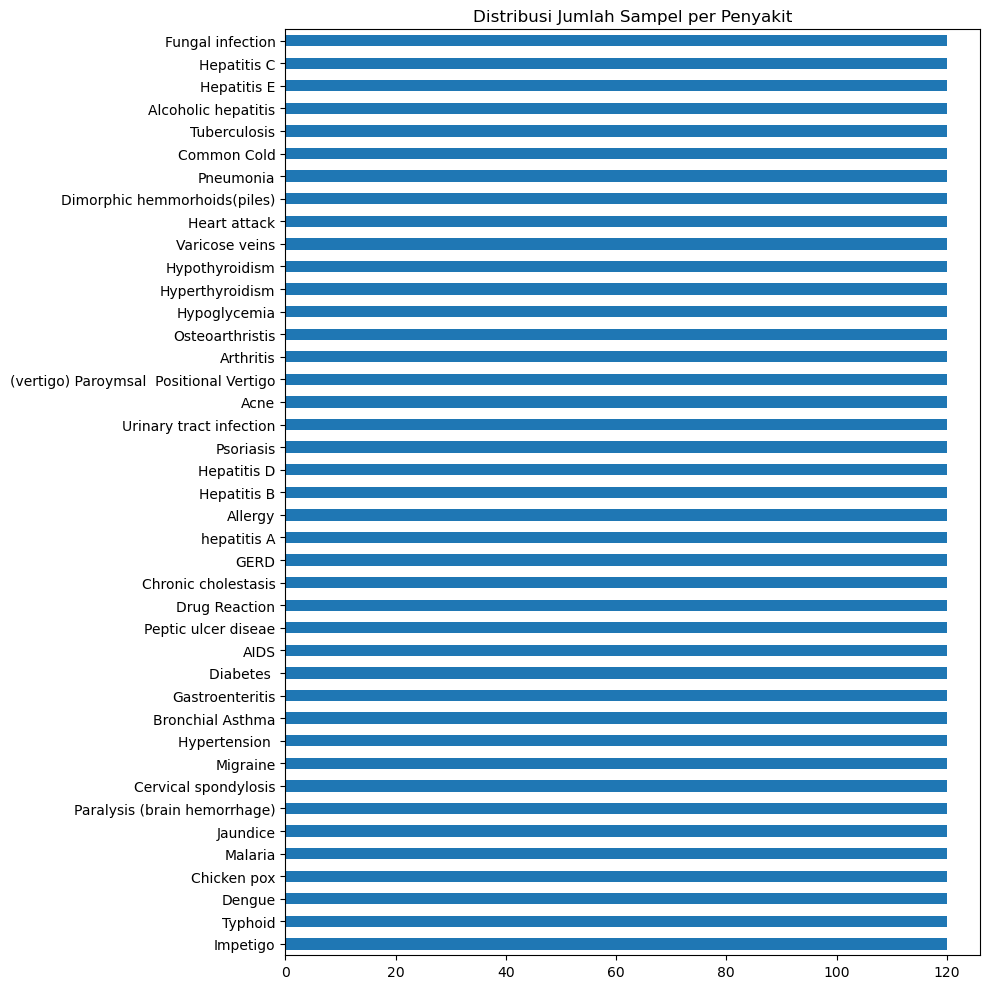

In [6]:
plt.figure(figsize=(10,10))
df_raw['Disease'].value_counts().plot(kind='barh')
plt.title("Distribusi Jumlah Sampel per Penyakit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
counts = df_raw['Disease'].value_counts()
print("Rasio sampel terbanyak vs tersedikit:", counts.max() / counts.min())

Rasio sampel terbanyak vs tersedikit: 1.0


### Step 4 - One Hot Encoding Gejala

In [8]:
symptom_cols = [c for c in df_raw.columns if 'Symptom' in c]
print("Kolom gejala:", symptom_cols)

for col in symptom_cols:
    df_raw[col] = df_raw[col].astype(str).str.strip().str.lower()
    df_raw[col] = df_raw[col].str.replace(r'[\s_]+', '_', regex=True)
    df_raw[col] = df_raw[col].replace('nan', np.nan)

Kolom gejala: ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


In [9]:
all_symptoms = pd.unique(df_raw[symptom_cols].values.ravel())
all_symptoms = sorted([s for s in all_symptoms if pd.notna(s)])
print("Jumlah gejala unik:", len(all_symptoms))
print(all_symptoms[:20])

Jumlah gejala unik: 131
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills']


### Step 4b - Cek kemungkinan nama gejala yang mirip (typo)

In [10]:
import difflib

potensi_duplikat = []
for i, s in enumerate(all_symptoms):
    matches = difflib.get_close_matches(s, all_symptoms[i+1:], n=3, cutoff=0.9)
    for m in matches:
        potensi_duplikat.append((s, m))

print("Jumlah pasangan gejala yang mirip (cutoff 0.9):", len(potensi_duplikat))
for pair in potensi_duplikat[:20]:
    print(pair)

Jumlah pasangan gejala yang mirip (cutoff 0.9): 0


In [11]:
for symptom in all_symptoms:
    df_raw[symptom] = df_raw[symptom_cols].apply(
        lambda row: symptom in row.values, axis=1
    ).astype(int)

df_final = df_raw.drop(columns=symptom_cols)
df_final = df_final.drop_duplicates()
print("Shape setelah encoding & hapus duplikat:", df_final.shape)
df_final.head()

Shape setelah encoding & hapus duplikat: (304, 132)


,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,blister,blood_in_sputum,bloody_stool,blurred_and_distorted_vision,breathlessness,brittle_nails,bruising,burning_micturition,chest_pain,chills,cold_hands_and_feets,coma,congestion,constipation,continuous_feel_of_urine,continuous_sneezing,cough,cramps,dark_urine,dehydration,depression,diarrhoea,dischromic_patches,distention_of_abdomen,dizziness,drying_and_tingling_lips,enlarged_thyroid,excessive_hunger,extra_marital_contacts,family_history,fast_heart_rate,fatigue,fluid_overload,foul_smell_of_urine,headache,high_fever,hip_joint_pain,history_of_alcohol_consumption,increased_appetite,indigestion,inflammatory_nails,internal_itching,irregular_sugar_level,irritability,irritation_in_anus,itching,joint_pain,knee_pain,lack_of_concentration,lethargy,loss_of_appetite,loss_of_balance,loss_of_smell,malaise,mild_fever,mood_swings,movement_stiffness,mucoid_sputum,muscle_pain,muscle_wasting,muscle_weakness,nausea,neck_pain,nodal_skin_eruptions,obesity,pain_behind_the_eyes,pain_during_bowel_movements,pain_in_anal_region,painful_walking,palpitations,passage_of_gases,patches_in_throat,phlegm,polyuria,prominent_veins_on_calf,puffy_face_and_eyes,pus_filled_pimples,receiving_blood_transfusion,receiving_unsterile_injections,red_sore_around_nose,red_spots_over_body,redness_of_eyes,restlessness,runny_nose,rusty_sputum,scurring,shivering,silver_like_dusting,sinus_pressure,skin_peeling,skin_rash,slurred_speech,small_dents_in_nails,spinning_movements,spotting_urination,stiff_neck,stomach_bleeding,stomach_pain,sunken_eyes,sweating,swelled_lymph_nodes,swelling_joints,swelling_of_stomach,swollen_blood_vessels,swollen_extremeties,swollen_legs,throat_irritation,toxic_look_(typhos),ulcers_on_tongue,unsteadiness,visual_disturbances,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
os.makedirs(PROCESSED_DIR, exist_ok=True)
df_final.to_csv(os.path.join(PROCESSED_DIR, "disease_symptoms_encoded.csv"), index=False)

### Step 5 - X,Y Split & Train-Test Split

In [13]:
X = df_final.drop(columns=['Disease'])
y = df_final['Disease']

print("Jumlah fitur (gejala):", X.shape[1])
print("Jumlah kelas (penyakit):", y.nunique())

Jumlah fitur (gejala): 131
Jumlah kelas (penyakit): 41


In [14]:
class_counts = y.value_counts()
print("Kelas dengan sampel < 2:")
print(class_counts[class_counts < 2])

valid_classes = class_counts[class_counts >= 2].index
df_final = df_final[df_final['Disease'].isin(valid_classes)]
X = df_final.drop(columns=['Disease'])
y = df_final['Disease']

Kelas dengan sampel < 2:
Series([], Name: Disease, dtype: int64)


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(le, os.path.join(MODELS_DIR, "label_encoder.pkl"))

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (243, 131) Test: (61, 131)


### Step 6 - Training Some Model

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": BernoulliNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start

    y_pred_train = model.predict(X_train)
    y_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(acc, 4),
        "F1-macro": round(f1, 4),
        "Waktu(s)": round(duration, 2),
    })

results_df = pd.DataFrame(results).sort_values("F1-macro", ascending=False)
results_df

,Model,Train Accuracy,Test Accuracy,F1-macro,Waktu(s)
1,Random Forest,1.0000,1.0000,1.0000,0.55
3,Logistic Regression,1.0000,1.0000,1.0000,0.22
2,Naive Bayes,0.9877,0.9672,0.9545,0.02
0,Decision Tree,1.0000,0.6557,0.5699,0.01


### Step 7 - Evaluasi Model Terbaik

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Model terbaik:", best_model_name)

y_pred = best_model.predict(X_test)

Model terbaik: Random Forest


In [18]:
from sklearn.metrics import classification_report

labels_present = sorted(set(y_test) | set(y_pred))
target_names = le.inverse_transform(labels_present)
print(classification_report(y_test, y_pred, labels=labels_present, target_names=target_names))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.00      1.00      1.00         2
                           

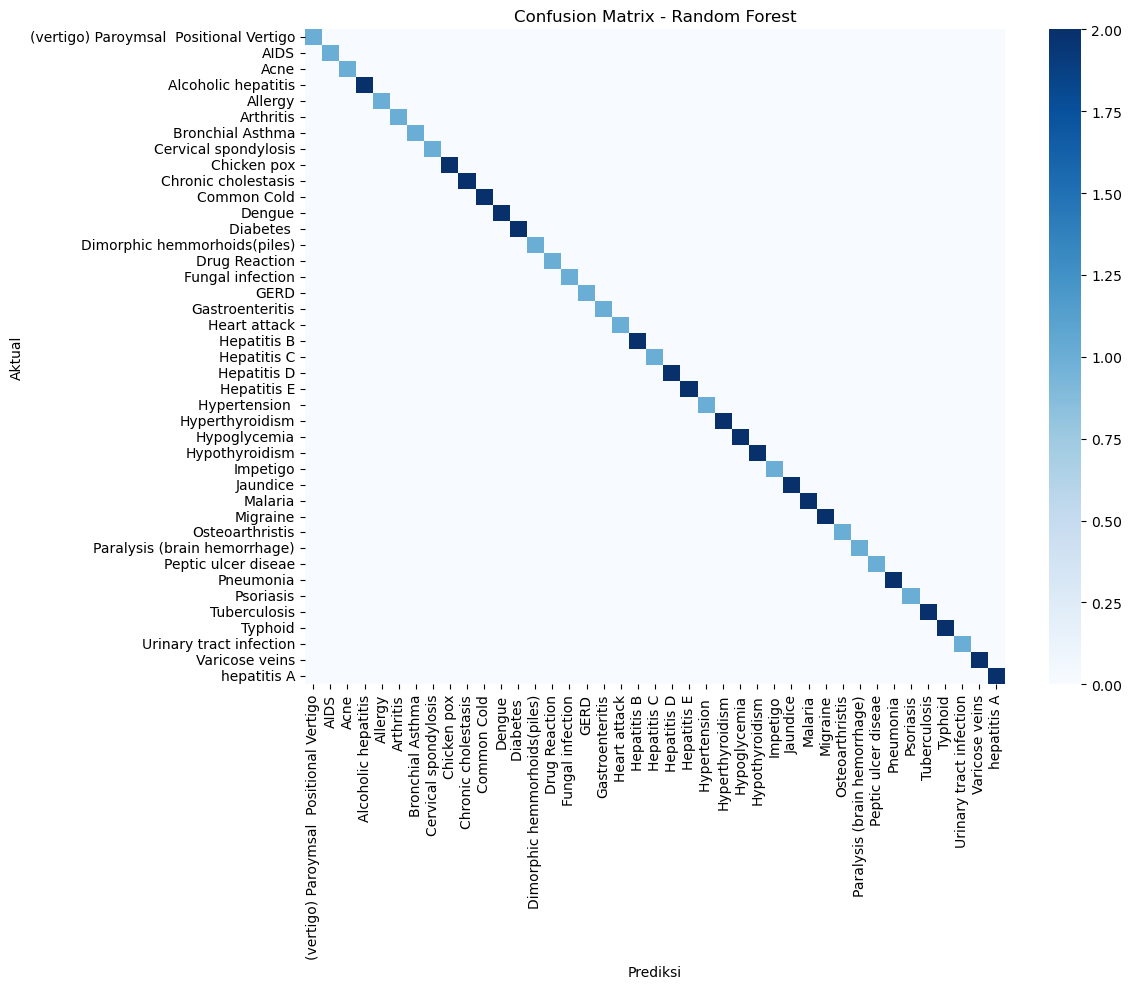

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=labels_present)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

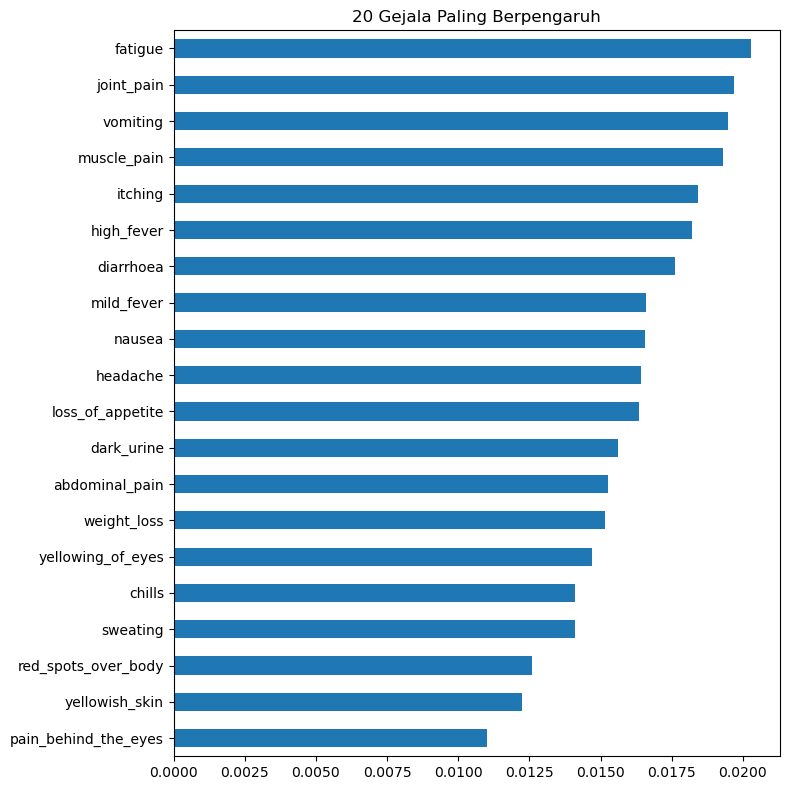

In [20]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances.sort_values(ascending=False).head(20).plot(kind='barh', figsize=(8,8))
    plt.title("20 Gejala Paling Berpengaruh")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} tidak mendukung feature_importances_")

### Step 8 - Cross Validation

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X_train, y_train, cv=skf, scoring='f1_macro')

print("F1-macro tiap fold:", scores)
print("Rata-rata:", scores.mean(), "+/-", scores.std())

F1-macro tiap fold: [1. 1. 1. 1. 1.]
Rata-rata: 1.0 +/- 0.0


### Step 9 - Tabel Referensi

In [22]:
df_specialist = pd.read_csv(
    os.path.join(RAW_DIR, "Doctor_Versus_Disease.csv"),
    header=None,
    names=['Disease', 'Specialist'],
    encoding='latin1'
)

print(df_specialist.shape)
df_specialist.head(10)

(41, 2)


,Disease,Specialist
0,Drug Reaction,Allergist
1,Allergy,Allergist
2,Hypertension,Cardiologist
3,Heart attack,Cardiologist
4,Psoriasis,Dermatologist
5,Chicken pox,Dermatologist
6,Acne,Dermatologist
7,Impetigo,Dermatologist
8,Fungal infection,Dermatologist
9,Hypothyroidism,Endocrinologist


In [23]:
df_valid_specialist = dataframes["Doctor_Specialist.csv"]
valid_specialists = set(df_valid_specialist.iloc[:, 0].str.strip())
used_specialists = set(df_specialist['Specialist'].str.strip())

specialis_tidak_valid = used_specialists - valid_specialists
print("Spesialis yang dipakai tapi TIDAK ada di daftar resmi:")
print(specialis_tidak_valid)

Spesialis yang dipakai tapi TIDAK ada di daftar resmi:
{'Tuberculosis', 'hepatologist'}


In [24]:
df_precaution = dataframes["Disease precaution.csv"].copy()
df_description = dataframes["Disease_Description.csv"].copy()

def clean_disease_name(s):
    return str(s).strip().lower()

df_specialist['disease_clean'] = df_specialist['Disease'].apply(clean_disease_name)
df_precaution['disease_clean'] = df_precaution.iloc[:, 0].apply(clean_disease_name)
df_description['disease_clean'] = df_description.iloc[:, 0].apply(clean_disease_name)

lookup = df_specialist[['disease_clean', 'Disease', 'Specialist']].drop_duplicates().copy()
lookup = lookup.merge(
    df_description[['disease_clean', df_description.columns[1]]],
    on='disease_clean', how='left'
)
lookup = lookup.merge(
    df_precaution.drop(columns=[df_precaution.columns[0]]),
    on='disease_clean', how='left'
)

print("Jumlah baris lookup:", lookup.shape[0])
print("Jumlah NaN per kolom:")
print(lookup.isnull().sum())

os.makedirs(PROCESSED_DIR, exist_ok=True)
lookup.to_csv(os.path.join(PROCESSED_DIR, "disease_lookup.csv"), index=False)
lookup.head(10)

Jumlah baris lookup: 41
Jumlah NaN per kolom:
disease_clean    0
Disease          0
Specialist       0
Description      1
Precaution_1     0
Precaution_2     0
Precaution_3     1
Precaution_4     1
dtype: int64


,disease_clean,Disease,Specialist,Description,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,drug reaction,Drug Reaction,Allergist,An adverse drug reaction (ADR) is an injury ca...,stop irritation,consult nearest hospital,stop taking drug,follow up
1,allergy,Allergy,Allergist,An allergy is an immune system response to a f...,apply calamine,cover area with bandage,NaN,use ice to compress itching
2,hypertension,Hypertension,Cardiologist,"Hypertension (HTN or HT), also known as high b...",meditation,salt baths,reduce stress,get proper sleep
3,heart attack,Heart attack,Cardiologist,The death of heart muscle due to the loss of b...,call ambulance,chew or swallow asprin,keep calm,NaN
4,psoriasis,Psoriasis,Dermatologist,Psoriasis is a common skin disorder that forms...,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
5,chicken pox,Chicken pox,Dermatologist,Chickenpox is a highly contagious disease caus...,use neem in bathing,consume neem leaves,take vaccine,avoid public places
6,acne,Acne,Dermatologist,"Acne vulgaris is the formation of comedones, p...",bath twice,avoid fatty spicy food,drink plenty of water,avoid too many products
7,impetigo,Impetigo,Dermatologist,Impetigo (im-puh-TIE-go) is a common and highl...,soak affected area in warm water,use antibiotics,remove scabs with wet compressed cloth,consult doctor
8,fungal infection,Fungal infection,Dermatologist,"In humans, fungal infections occur when an inv...",bath twice,use detol or neem in bathing water,keep infected area dry,use clean cloths
9,hypothyroidism,Hypothyroidism,Endocrinologist,"Hypothyroidism, also called underactive thyroi...",reduce stress,exercise,eat healthy,get proper sleep


### Step 10 - Save Models

In [25]:
joblib.dump(best_model, os.path.join(MODELS_DIR, "disease_model.pkl"))
joblib.dump(list(X_train.columns), os.path.join(MODELS_DIR, "symptom_columns.pkl"))
joblib.dump(le, os.path.join(MODELS_DIR, "label_encoder.pkl"))
lookup.to_pickle(os.path.join(MODELS_DIR, "disease_lookup.pkl"))
results_df.to_csv(os.path.join(MODELS_DIR, "model_comparison_results.csv"), index=False)

### Step 11 - Prediction Function

In [26]:
def predict_full(gejala_user, model, symptom_columns, label_encoder, lookup_table):
    gejala_dikenal = [g for g in gejala_user if g in symptom_columns]
    gejala_tidak_dikenal = [g for g in gejala_user if g not in symptom_columns]

    if gejala_tidak_dikenal:
        print("Peringatan, gejala berikut tidak dikenali dan diabaikan:", gejala_tidak_dikenal)

    input_vector = pd.DataFrame(
        [[1 if col in gejala_dikenal else 0 for col in symptom_columns]],
        columns=symptom_columns
    )

    pred_encoded = model.predict(input_vector)[0]
    pred_disease = label_encoder.inverse_transform([pred_encoded])[0]

    proba = model.predict_proba(input_vector)[0]
    top3_idx = np.argsort(proba)[-3:][::-1]
    top3 = [(label_encoder.inverse_transform([i])[0], round(proba[i]*100, 2)) for i in top3_idx]

    info = lookup_table[lookup_table['disease_clean'] == pred_disease.strip().lower()]

    if len(info) > 0:
        info_tambahan = info.to_dict('records')[0]
    else:
        info_tambahan = {col: None for col in lookup_table.columns}
        info_tambahan['Disease'] = pred_disease

    return {
        "prediksi_utama": pred_disease,
        "top3_kemungkinan": top3,
        "gejala_tidak_dikenal": gejala_tidak_dikenal,
        "info_tambahan": info_tambahan
    }

In [27]:
symptom_columns = joblib.load(os.path.join(MODELS_DIR, "symptom_columns.pkl"))
print("Contoh nama gejala yang valid (30 pertama):", symptom_columns[:30])

gejala_test = [s for s in ['itching', 'skin_rash', 'nodal_skin_eruptions'] if s in symptom_columns]
if not gejala_test:
    gejala_test = list(symptom_columns[:3])

hasil = predict_full(gejala_test, best_model, symptom_columns, le, lookup)
print(json.dumps(hasil, indent=2, default=str))

Contoh nama gejala yang valid (30 pertama): ['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration']
{
  "prediksi_utama": "Fungal infection",
  "top3_kemungkinan": [
    [
      "Fungal infection",
      77.0
    ],
    [
      "Drug Reaction",
      7.0
    ],
    [
      "Acne",
      4.0
    ]
  ],
  "gejala_tidak_dikenal": [],
  "info_tambahan": {
    "disease_clean": "fungal infection",
    "Disease": "Fungal infection",
    "Specialist": "Dermatologist",
    "Description": "In humans, fungal infections occur when an invading fungus takes 